#  Supposedly great title sketchGJ  

Description


In [ ]:
print("I'm working")

I'm working


In [ ]:
%pip install uproot awkward matplotlib numpy

In [27]:
import uproot
import matplotlib.pyplot as plt #likely redund.
import numpy as np
import pandas as pd
import awkward as ak
import re
import math
import ROOT 
import os, sys, importlib

os.chdir('/scratch1/gjedrzej/Lab') #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

## All Data 0.5-30 GeV Taon Decay

In [ ]:
FilePath = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path = os.path.join(output_dir, 'data_all_tau.csv')
kg.extract_data(FilePath, output_path)
df = pd.read_csv(output_path)

In [ ]:
pf.visualize_kg(df)
pf.logger(df)

## All Data 0.5-30 GeV Stable Taon

In [ ]:
FilePath = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_stabkeTau_interactions.gtrac.root"
output_path = os.path.join(output_dir, 'data_all_tau_stable.csv')
kg.extract_data(FilePath, output_path)
df = pd.read_csv(output_path)

In [ ]:
pf.visualize_kg(df)
pf.logger(df)

# All data 0.5-80 (Full NC)

In [24]:
FilePath = "/scratch1/gjedrzej/Lab/Legacy_data/Tests/nu_tau_05__80_interactions.gtrac.root"
output_path = os.path.join(output_dir, 'data_tau.csv')
sk.extract_data_hybrid(FilePath, output_path)

Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_tau.csv


In [25]:
output_path_KG = os.path.join(output_dir, 'data_all_old.csv')
kg.extract_data(FilePath, output_path_KG)
df = pd.read_csv(output_path_KG)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97767 entries, 0 to 97766
Columns: 144 entries, EvtNum to E_20
dtypes: float64(140), int64(2), object(2)
memory usage: 107.4+ MB


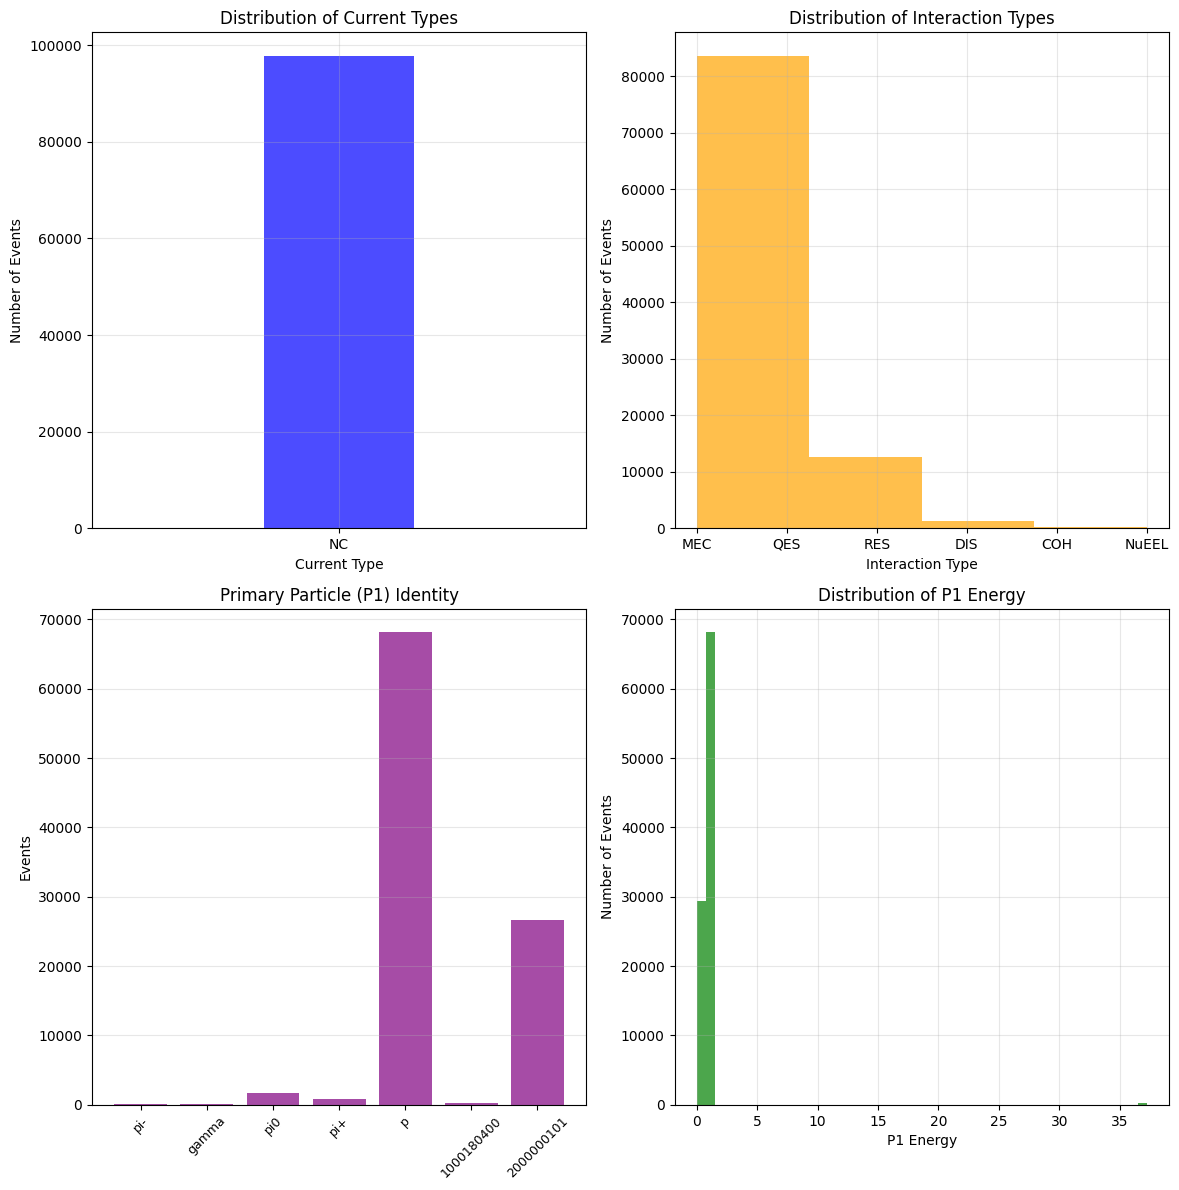

In [29]:
pf.visualize_kg(df)

In [12]:
df = pd.read_csv(output_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   EvtNum           100000 non-null  int64  
 1   CurrentType      100000 non-null  object 
 2   InteractionType  100000 non-null  object 
 3   P1_id            34588 non-null   float64
 4   P1_px            34588 non-null   float64
 5   P1_py            34588 non-null   float64
 6   P1_pz            34588 non-null   float64
 7   P1_E             34588 non-null   float64
 8   P2_id            4338 non-null    float64
 9   P2_px            4338 non-null    float64
 10  P2_py            4338 non-null    float64
 11  P2_pz            4338 non-null    float64
 12  P2_E             4338 non-null    float64
 13  P3_id            99 non-null      float64
 14  P3_px            99 non-null      float64
 15  P3_py            99 non-null      float64
 16  P3_pz            99 non-null      float

In [13]:
#clean nulls
print(f"Number of events before cleaning: {len(df)}")
df = df.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
df.info()
df.head()
print(f"Number of events after cleaning: {len(df)}")

Number of events before cleaning: 100000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   EvtNum           100000 non-null  int64  
 1   CurrentType      100000 non-null  object 
 2   InteractionType  100000 non-null  object 
 3   P1_id            34588 non-null   float64
 4   P1_px            34588 non-null   float64
 5   P1_py            34588 non-null   float64
 6   P1_pz            34588 non-null   float64
 7   P1_E             34588 non-null   float64
 8   P2_id            4338 non-null    float64
 9   P2_px            4338 non-null    float64
 10  P2_py            4338 non-null    float64
 11  P2_pz            4338 non-null    float64
 12  P2_E             4338 non-null    float64
 13  P3_id            99 non-null      float64
 14  P3_px            99 non-null      float64
 15  P3_py            99 non-null      float64
 16

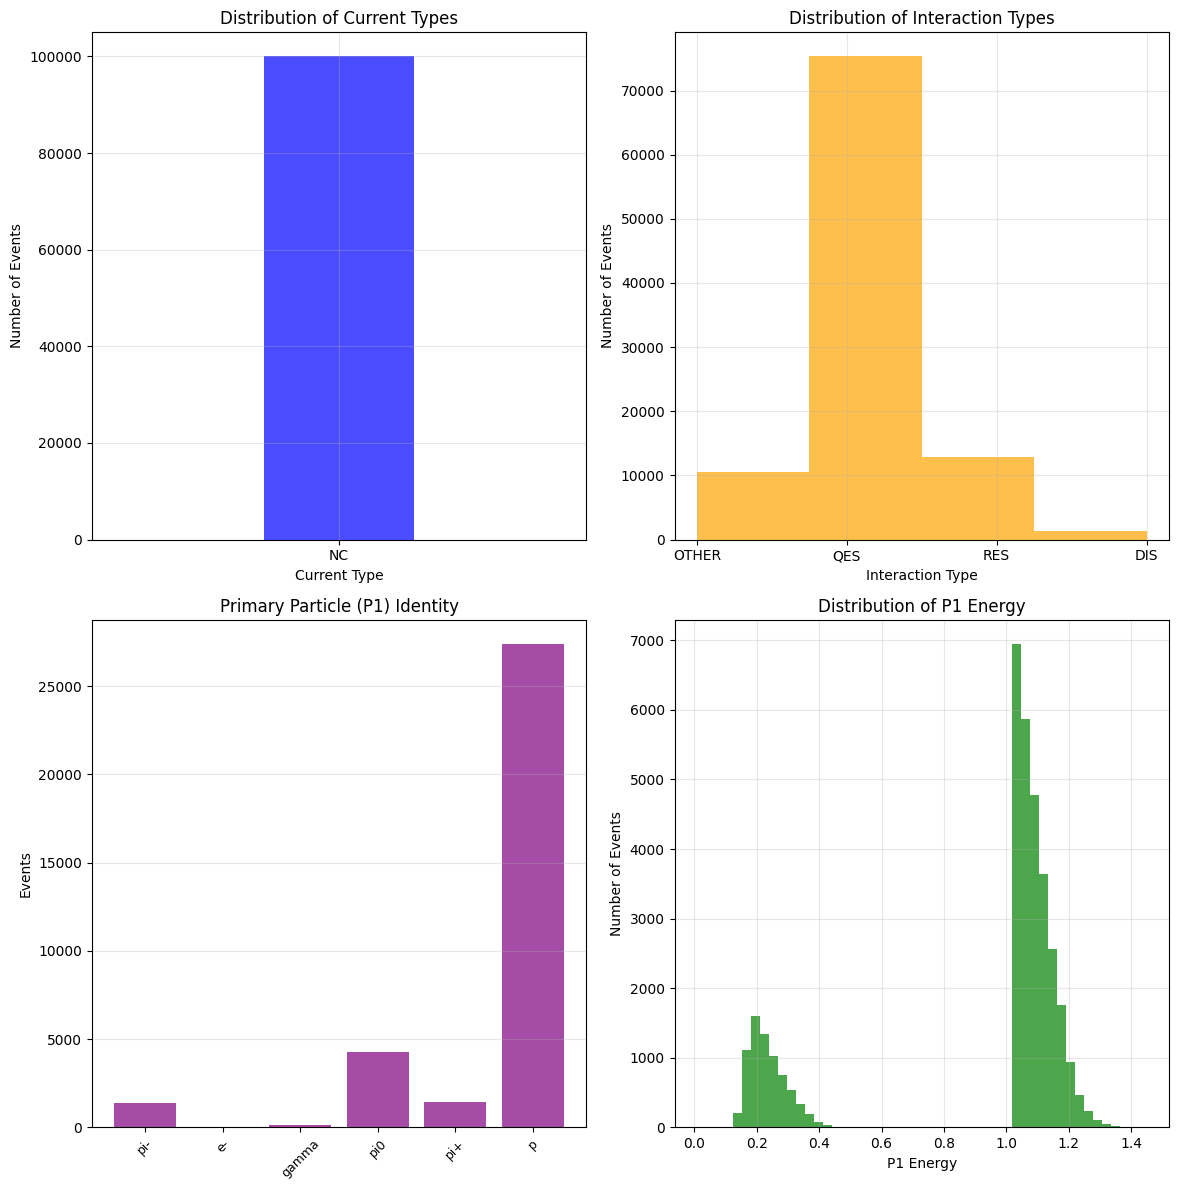

In [18]:
pf.visualize_data(df)

# All Data 3.5-50

In [ ]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_3_5__50_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_CC_NC.csv')
sk.extract_data_hybrid(file, output_path)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_CC_NC.csv


NameError: name 'visualize_data' is not defined

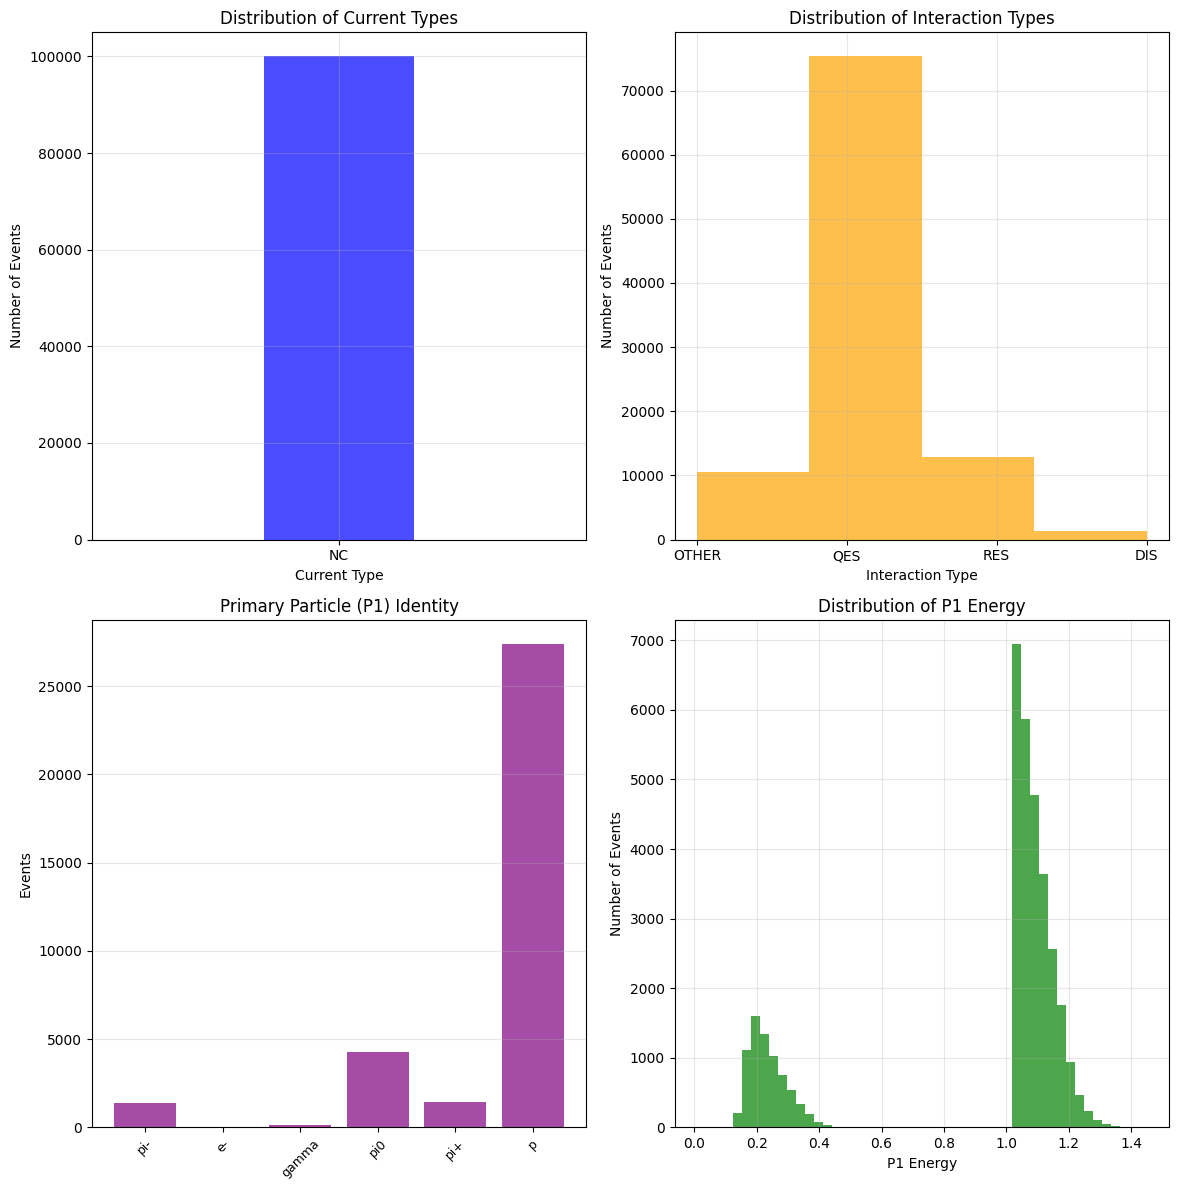

In [21]:
df_cc_nc = pd.read_csv(output_path)
df_cc_nc = df_cc_nc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
pf.visualize_data(df_cc_nc)

In [22]:
pf.logger(df_cc_nc)

CC percentage: 0.0
Expected CC percentage: ~3.8%
NC percentage: 100.0
Expected NC percentage: ~96.2%
CC QES percentage: nan
Expected CC QES percentage: ~51%


/scratch1/gjedrzej/Lab/analysis/scripts/plotting_functions.py:46: RuntimeWarning: invalid value encountered in scalar divide
  print("CC QES percentage:", ((df['CurrentType'] == 'CC') & (df['InteractionType'] == 'QES')).sum() / df['CurrentType'].eq('CC').sum() * 100)


# CC    3-80 GeV

In [13]:
%%time
file = '/scratch1/gjedrzej/Lab/data/nu_tau_CC_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_CC.csv')
extract_data_hybrid(file, output_path, neutral_particles)

Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_CC.csv
CPU times: user 4min 43s, sys: 1.48 s, total: 4min 45s
Wall time: 4min 44s


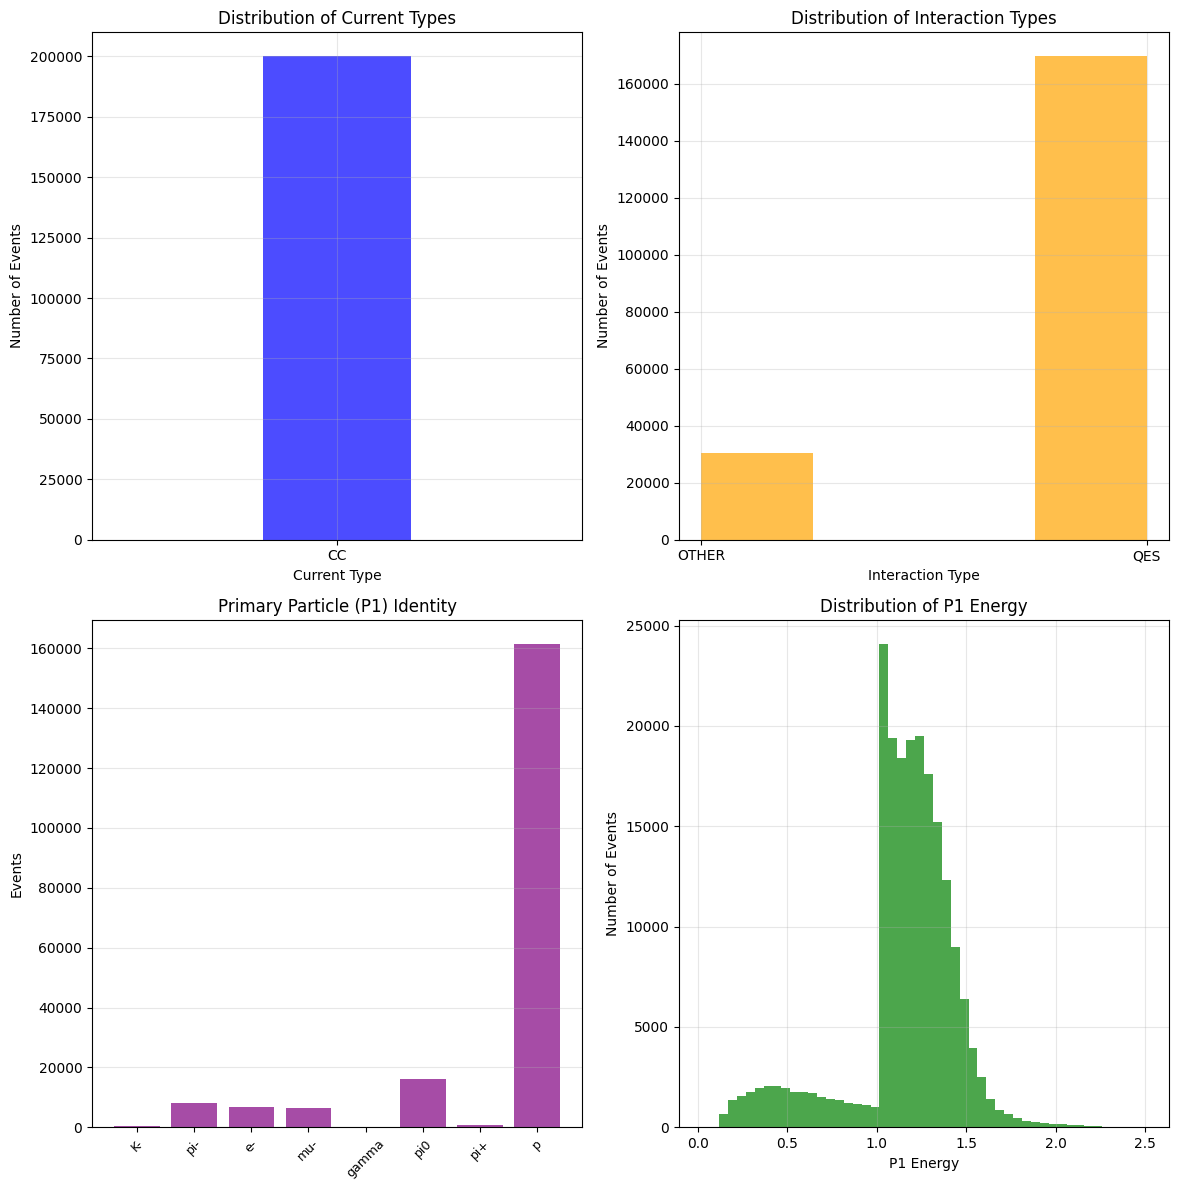

In [ ]:
df_cc = pd.read_csv(output_path)
df_cc = df_cc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
pf.visualize_data(df_cc)

In [ ]:
print("CC QES percentage:", ((df_cc['CurrentType'] == 'CC') & (df_cc['InteractionType'] == 'QES')).sum() / df_cc['CurrentType'].eq('CC').sum() * 100)
print("Expected CC QES percentage: ~51%")
#use logger and compare output

CC QES percentage: 84.803
Expected CC QES percentage: ~51%


# NC 1-10 GeV

In [ ]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_NC_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_NC.csv')
sk.extract_data_hybrid(file, output_path)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_NC.csv


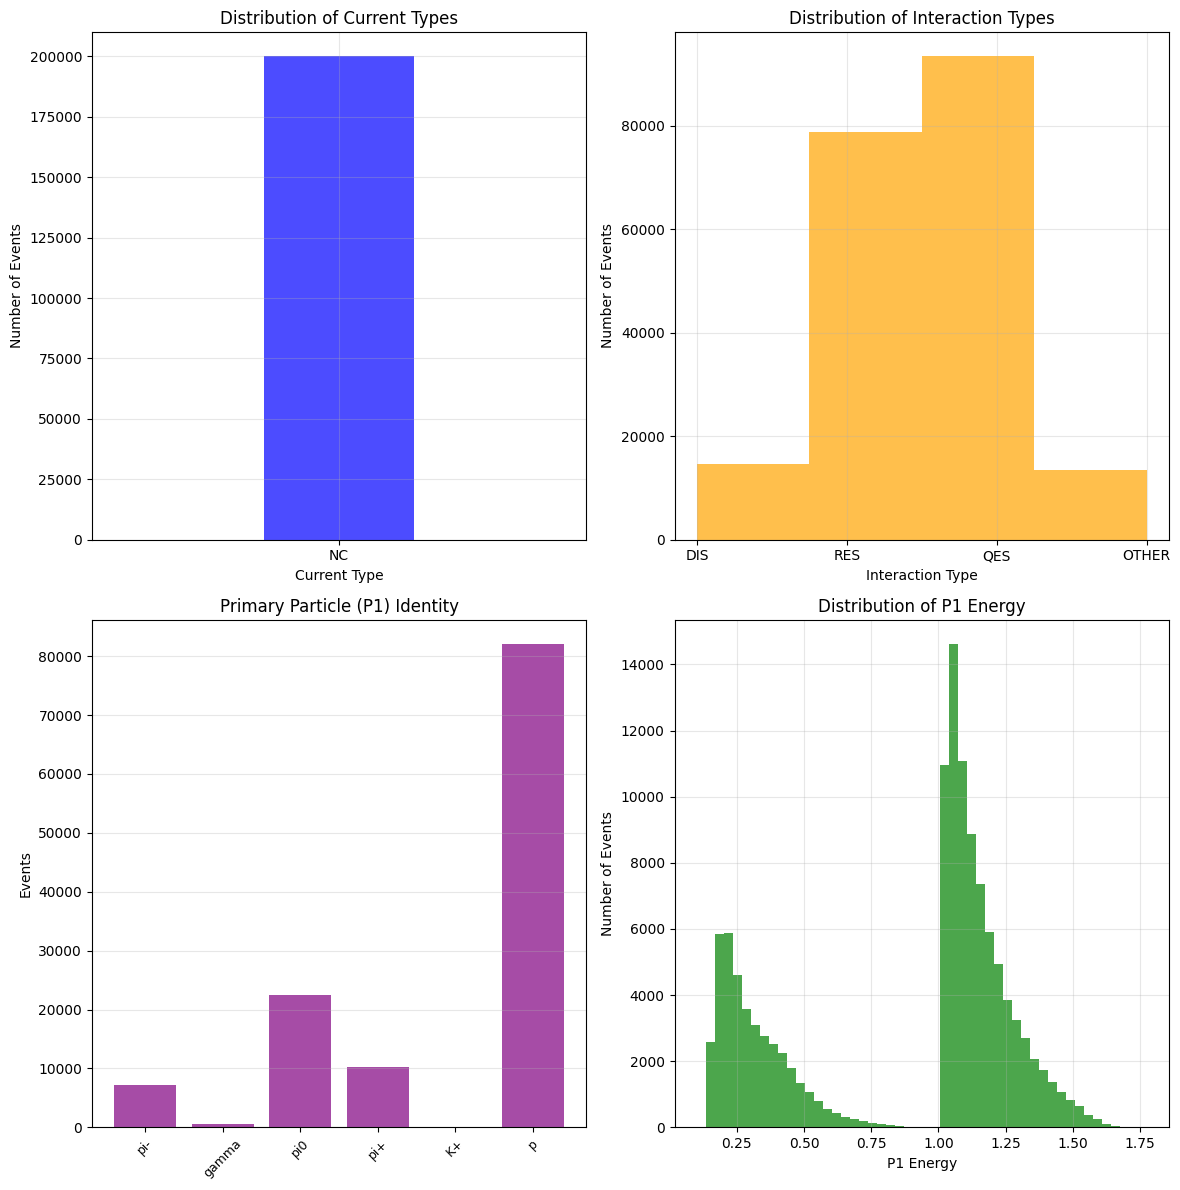

In [ ]:
df_nc = pd.read_csv(output_path)
df_nc = df_nc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
pf.visualize_data(df_nc)

# NC_2 3-10 GeV

In [ ]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_NC2_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_NC2.csv')
sk.extract_data_hybrid(file, output_path)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_NC2.csv


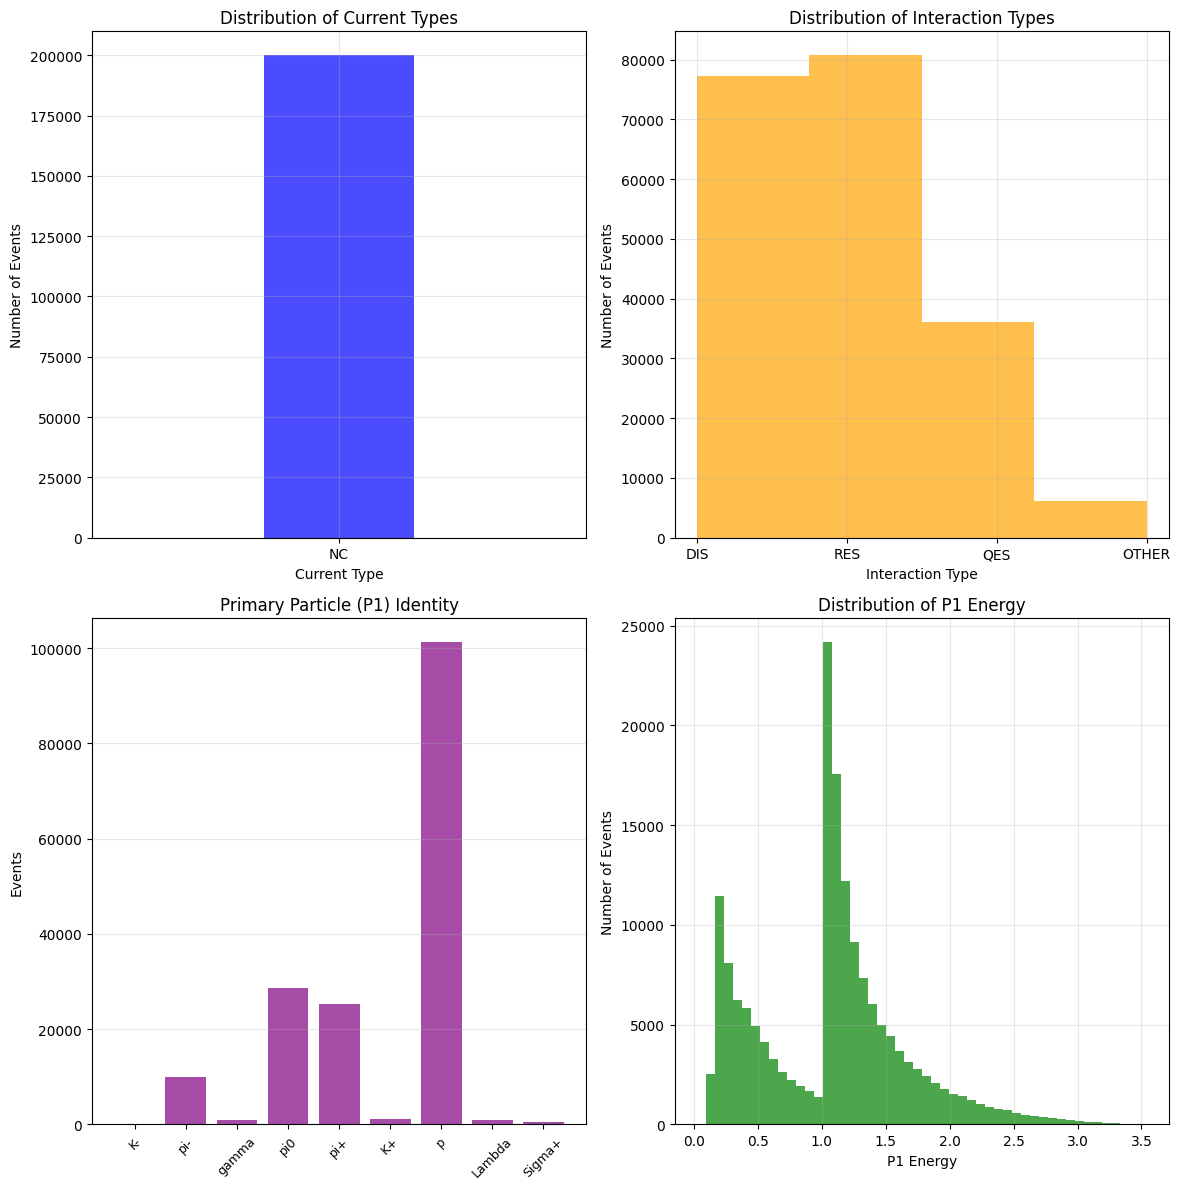

In [ ]:
df_nc2 = pd.read_csv(output_path)
df_nc2 = df_nc2.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
pf.visualize_data(df_nc2)

# CC Energy (needs clarification)

In [ ]:
# def plot_CC_energy(df):
#     fig, axes = plt.subplots(2, 2, figsize=(12, 12))

#     # --- axes[0,0]: Total Distribution of all tau (PDG 15) ---
#     all_tau_energies = []
#     for i in range(1, 5):
#         mask = df[f'P{i}_id'] == 15
#         all_tau_energies.extend(df.loc[mask, f'P{i}_E'].dropna())

#     axes[0,0].hist(all_tau_energies, bins=50, alpha=0.7, color='blue', edgecolor='black')
#     axes[0,0].set_title("Energy of all tau (PDG 15) in event")
#     axes[0,0].set_xlabel("Energy [GeV]")

#     # --- axes[0,1]: nu_tau Energy by Interaction Type ---
#     colors = {'DIS': 'orange', 'RES': 'green', 'QES': 'red', 'OTHER': 'gray'}
    
#     # We iterate over unique interaction types found in the data
#     for int_type in df['InteractionType'].unique():
#         int_subset = df[df['InteractionType'] == int_type]
#         type_energies = []
        
#         # Check all 4 particle slots for this specific interaction type
#         for i in range(1, 5):
#             mask = int_subset[f'P{i}_id'] == 15
#             type_energies.extend(int_subset.loc[mask, f'P{i}_E'].dropna())
        
#         # Plot if we actually found any nu_taus for this type
#         if type_energies:
#             axes[0,1].hist(type_energies, bins=50, alpha=0.5, 
#                            label=f"{int_type} (n={len(type_energies)})", 
#                            color=colors.get(int_type, 'blue'))

#     axes[0,1].set_title("tau Energy Grouped by Interaction")
#     axes[0,1].set_xlabel("Energy [GeV]")
#     axes[0,1].legend()
    

#     # --- axes[1,0]: Current Type (Placeholder - Expecting CC) ---
#     axes[1,0].hist(df['CurrentType'].astype(str), bins=3, color='purple', alpha=0.6)
#     axes[1,0].set_title("Distribution of Current Types")
#     axes[1,0].set_ylabel("Events")

    

#     # --- axes[1,1]: Interaction Type Counts (Placeholder) ---
#     axes[1,1].hist(df['InteractionType'], bins=4, alpha=0.7, color='orange')
#     axes[1,1].set_title("Distribution of Interaction Types")
#     axes[1,1].set_xlabel("Interaction Type")
#     axes[1,1].set_ylabel("Events")
#     axes[1,1].grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

/tmp/ipykernel_713233/824335172.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()


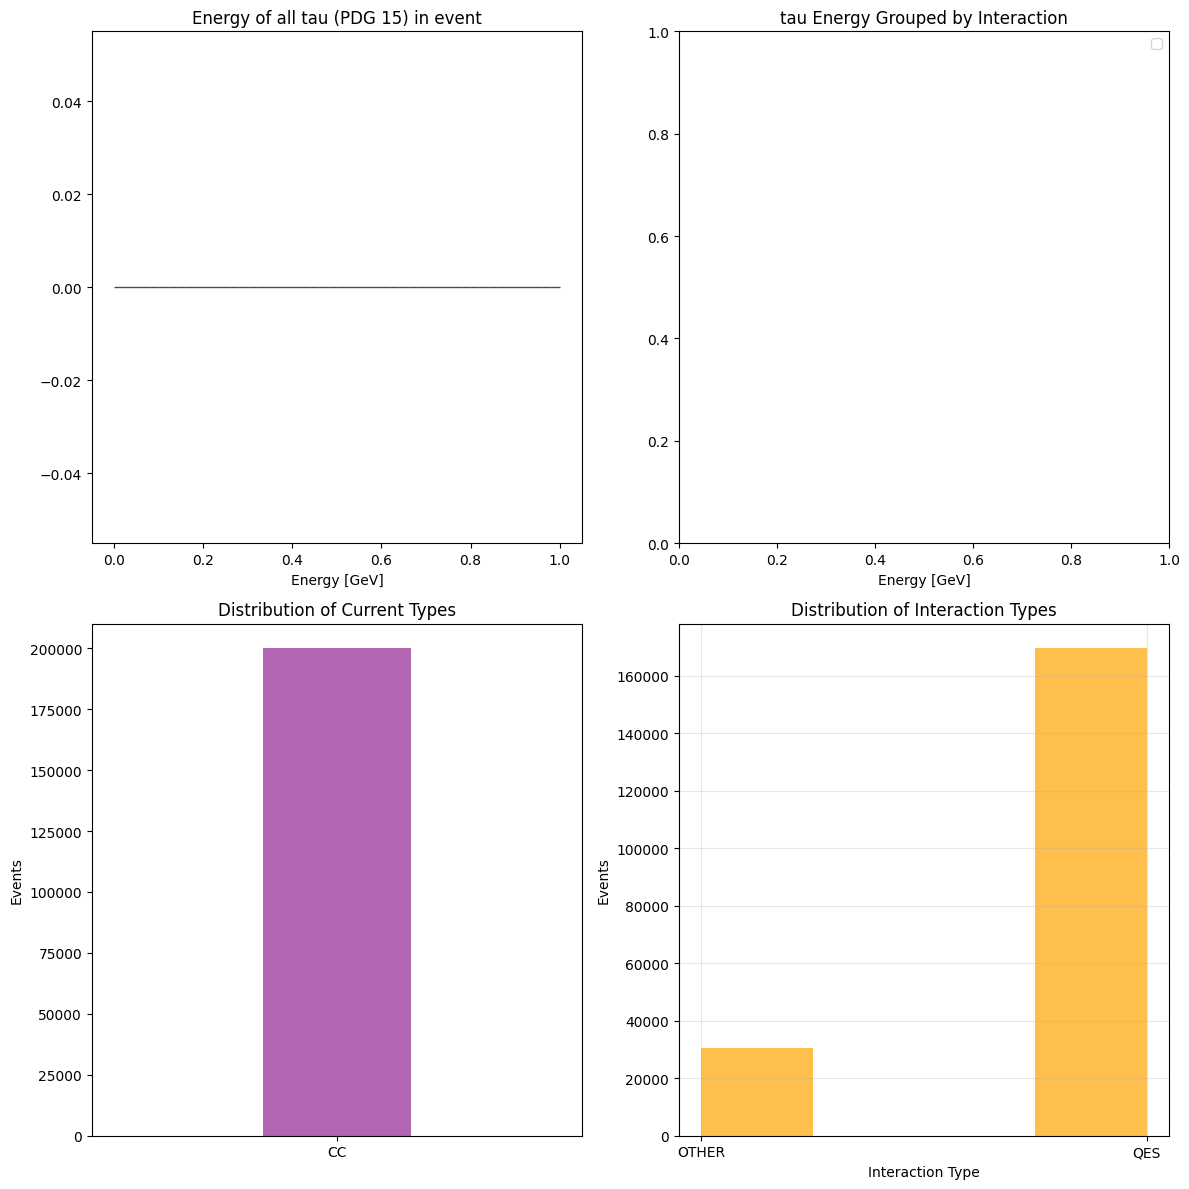

In [ ]:
# plot_CC_energy(df_cc)